# Simulating sinusoidal surface maps (gratings) with Finesse and FFT
Alina Soflau, 15.06.2026

This file is part of the hands-on session during the Finesse workshop at the ET Symposium in Aachen.

The surfaces of gravitational-wave detector mirrors are manufactured to extremely high precision, but still contain height defects at the nanometer scale. When illuminated by a laser beam, they introduce phase distortions and cause a redistribution of light. 

In this notebook, we use sinusoidal surface maps applied on an ET-scale mirror as controlled test cases. They produce diffraction features whose positions can be predicted analytically. The same optical configuration is simulated using:

* (i) Finesse - Hermite-Gauss modal propagation
* (ii) FFT propagation - grid based 

### The scope of this notebook is: 

* (i) Learn how to simulate a real ET map in Finesse, incorporating both phase and amplitude maps. 
* (ii) Study two different propagation methods: Finesse, FFT. Specifically FFT is used to cross-check Finesse results. 
* (iii) Investigate the convergence and limitations of both methods as a function of numerical parameters (`maxtem` for Finesse, and grid resolution for FFT)

## Simulation setup

We consider a Gaussian beam propagating towards a reflective mirror; a sinusoidal surface map is applied to the mirror surface. The reflected field is observed at the beam waist, because the beam is most compact there, making the diffraction features easier to visualise and compare. The same physical configuration is implemented in both Finesse and FFT simulations.

## Python imports and helpers

We use the following code block to load some extra packages and files into Google Colab if you are running this notebook there. The following cells load the Python libraries required by this notebook:

- `numpy` for numerical calculations,
- `matplotlib` for plotting,
- `finesse` for modal propagation,
- `ifotools` utilities for FFT propagation and mirror maps.

In [1]:

# This code block is only needed on Google Colab, you don't need this
# when running the notebook locally, but it can be executed without 
# causing any problems.

# install pypi wheel only on google colab
!env | grep -q 'colab' && pip install finesse git+https://gitlab.com/ifosim/ifotools.git@dbb86e36512178b2e02096b8b54311bbfd1e282f || echo 'Not on google colab, assuming finesse already installed'

# transfer extra files from github repository 
import os, urllib.request
REPO = "https://github.com/gwoptics/finesse3_workshop" 
#"https://raw.githubusercontent.com/<you>/<repo>/<branch>"

def ensure(path):
    if not os.path.exists(path):
        os.makedirs(os.path.dirname(path) or ".", exist_ok=True)
        urllib.request.urlretrieve(f"{REPO}/{path}", path)

# List all the files that the notebook expects to load
ASSETS = [
    "",
    ]

for f in ASSETS:
    ensure(f)


Not on google colab, assuming finesse already installed


In [2]:
import math
import numpy as np
import matplotlib.pyplot as plt

import finesse
from finesse.knm import Map
from finesse.utilities.maps import circular_aperture

from scipy.special import eval_hermite

from ifotools.fft_propagation import Grid, fft_propagate
from ifotools.grating import grating_sin
from ifotools.mirror_maps.utils import plot_map, cmap_r

## Helper functions

The FFT simulation requires an explicit Gaussian field on a transverse grid. The following helper functions are used to construct Hermite-Gaussian fields from the complex beam parameter `q`.

You do not need to modify these functions during the workshop.

In [3]:
def q2w(q, Lambda, nr=1):
    return np.abs(q) * np.sqrt(Lambda / (nr * np.pi * q.imag))

def q2w0(q, Lambda, nr=1):
    return np.sqrt(q.imag * Lambda / (nr * np.pi))

def U_n(x, n, q, Lambda):
    w0_local = q2w0(q, Lambda)
    pre = (2.0/np.pi)**0.25
    pre *= np.sqrt(1.0/(w0_local * 2**n * math.factorial(n)))
    pre *= np.sqrt(1j*q.imag / q)
    pre *= ((1j*q.imag * np.conjugate(q))/(-1j*q.imag * q))**(n/2.0)

    k = 2*np.pi/Lambda
    w = q2w(q, Lambda)
    return pre * eval_hermite(n, np.sqrt(2)/w * x) * np.exp(-0.5j * k * x*x / q)

def U_nm(x, y, n, m, q, Lambda):
    return np.outer(U_n(x, n, q, Lambda), U_n(y, m, q, Lambda))

## ET-HF optical configuration

The parameters used in both FFT and Finesse are representative of the ET-HF design described in the Einstein Telescope Design Report (2020).

In [4]:
# ET-HF optical parameters

RoC = 5070 # mirror radius of curvature [m]
Lambda = 1064e-9 # laser wavelength [m]
mirror_radius = 0.67 / 2  # mirror radius [m]
L_phys = 5000 # propagation distance [m]

# Round the length to an integer number of wavelengths
N = round(L_phys / Lambda)
L = N * Lambda  # propagation distance used in simulation [m]

## Gaussian beam

We construct a Gaussian beam that matches the curvature of the ET-HF mirror. The waist is located at the observation plane z=0, while the mirror is located at z=L. The Gaussian beam is described by the complex beam parameter $q(z)=z+i z_R$, where z_R is the Rayleigh range.

For a Gaussian beam, the wavefront radius of curvature at distance z from the waist is $R(z)=z\left(1+\frac{z_R^2}{z^2}\right)$. 

By requiring the beam curvature to match the mirror curvature at the mirror position, $R(L)=\mathrm{RoC}$, the Rayleigh range is $z_R=\sqrt{L(\mathrm{RoC}-L)}$. 

The waist radius then follows from $w_0=\sqrt{\frac{\lambda z_R}{\pi}}$. The corresponding complex beam parameters are

$$
q_{\mathrm{waist}} = q_{\mathrm{laser}} = i z_R,
$$

and

$$
q_{\mathrm{mirror}} = L + i z_R.
$$



These parameters are used by both methods: **Finesse** requires $w_0$ and $z$ to initialise the `gauss` component, after which the field propagation is handled internally; **FFT** requires $q(z)$ to construct the input field explicitly on the grid.

In [5]:
# Rayleigh range obtained by matching the mirror curvature
z_R = np.sqrt(L * (RoC - L))

# Waist radius
waist = np.sqrt(Lambda * z_R / np.pi)

# Complex beam parameters
q_waist = 1j * z_R
q_mirror = L + 1j * z_R

# Beam radius at the mirror
beam_radius_mirror = q2w(q_mirror, Lambda)

print(f"Distance from waist to mirror: {L:.3f} m")
print(f"Rayleigh range z_R: {z_R:.3f} m")
print(f"Waist radius w0: {waist:.4f} m")
print(f"Beam radius at mirror: {beam_radius_mirror:.4f} m")

Distance from waist to mirror: 5000.000 m
Rayleigh range z_R: 591.608 m
Waist radius w0: 0.0142 m
Beam radius at mirror: 0.1205 m


### 4. Mirror surface maps

The surface height is a sinusoidal grating described by

$$
h(x,y) = A \cos(2\pi f_s x),
$$

where A is the surface amplitude and $f_s$ is the spatial frequency. Upon reflection, due to the surface height perturbation $h(x,y)$, the field acquires a position dependent phase, given by: $\phi(x,y)=2k,h(x,y)$. Here the factor of 2 accounts for the double pass on reflection and $k=\frac{2\pi}{\lambda}$ is the light's wavevector. 

Real mirrors are also finite objects, and if beam clipping is relevant, this is captured by an amplitude map $a(x,y)$, a real-valued mask equal to 1 inside the mirror aperture and 0 outside. The total reflected field is then: $$E_\text{refl}(x,y) = a(x,y) \cdot E_\text{in}(x,y) \cdot e^{i\phi(x,y)}$$

In **Finesse**, these two maps are passed directly to the mirror object as `opd` and `amplitude`. 
In **FFT**, they are applied explicitly as multiplicative factors on the input field grid.

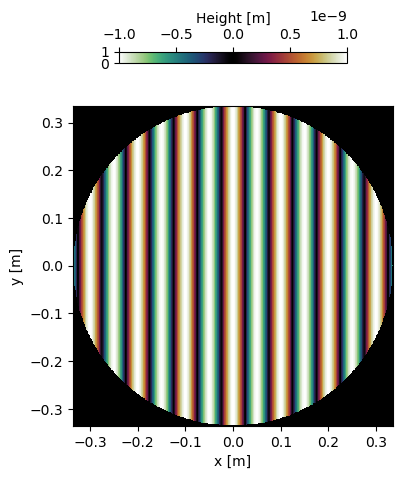

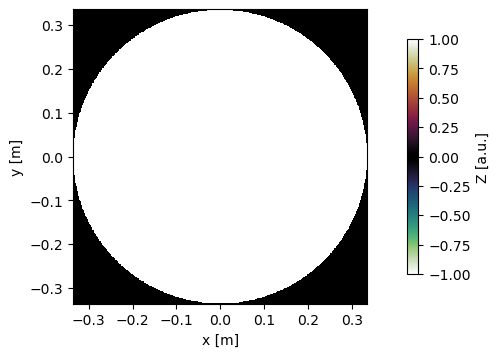

In [6]:
n_points = 501
frequency = 10  # spatial frequency [m^-1]
A = 1e-9 # grating amplitude [m]

# Sinusoidal surface height modulation of amplitude A and spatial frequency f, 
# defined on a circular disk of radius mirror_radius
x, y, phase = grating_sin(A, 1/frequency, mirror_radius, n_points)

amplitude = circular_aperture(x,y, mirror_radius) # 1 inside aperture, 0 outside. 

plot_map(x,y, phase, colormap=cmap_r, location='top', Z_label="Height [m]");
plot_map(x,y, amplitude);

## Finesse simulation

We first model the optical system using Finesse, which represents the optical field as a superposition of Hermite-Gaussian modes. 

We build a Finesse model consisting of a single mirror M1 illuminated by a laser l1. The Gaussian mode is defined by the waist w_0 and waist position z = 0. The sinusoidal surface map is applied as an OPD map on M1, and the reflected field is recorded on a camera placed at the observation plane z = 0. 


The modal basis is truncated at maxtem = 20. All global phases are retained (zero_k00=False, zero_tem00_gouy=False).

Beam parameter at the mirror:
BeamParam(w0=14.155 mm, z=5 km, w=120.47 mm, Rc=5.07 km)


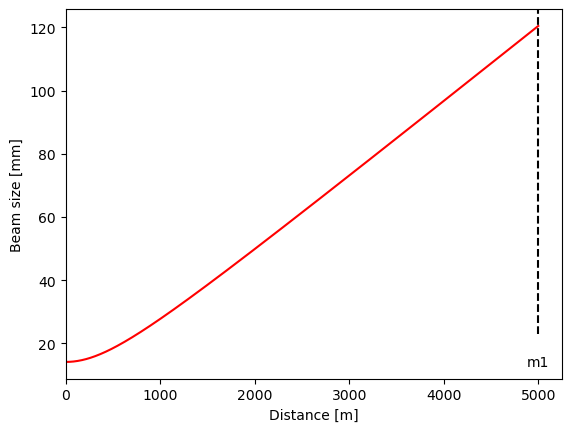

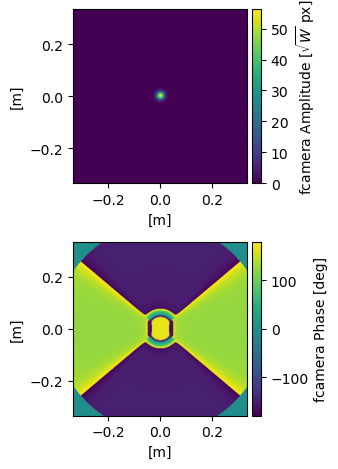

{finesse.detectors.camera.FieldCamera: [<Figure size 640x480 with 4 Axes>],
 'fcamera': <Figure size 640x480 with 4 Axes>}

In [7]:
# Camera size matches the mirror radius
xmax = mirror_radius

# Build the optical model
model = finesse.Model()

model.parse(f"""
l l1 P=1

# Gaussian beam matched to the ET-HF geometry
gauss g1 m1.p1.i w0={waist} z={L}

# Curved mirror
m m1 R=1 T=0 Rc={RoC}

# Propagation from observation plane to mirror
link(l1, {L}, m1)

# Camera placed at the observation plane
fcam fcamera l1.p1.i {xmax} {xmax} {n_points} f=0 w0_scaled=false
""")

# Apply phase and amplitude maps
model.m1.surface_map = Map(x, y, opd=phase, amplitude=amplitude)

# Modal basis truncation
model.modes(maxtem=20)

# keep the physical propagation phase
model.phase_config(zero_k00=False, zero_tem00_gouy=False)

# Run simulation
sol_map = model.run()

# verify the beam evolution
trace = finesse.tracing.tools.propagate_beam(from_node=model.l1.p1, to_node=model.m1.p1, direction="x")

print("Beam parameter at the mirror:")
print(model.m1.p1.i.qx)

trace.plot_beamsizes()


# Display camera field
sol_map.plot()

## 1D Intensity profile

The diffraction orders produced by nanometer-scale surface perturbations are much weaker than the main beam. To make them visible, we plot a one-dimensional cut along x=0 through the camera image on a logarithmic scale. For a sinusoidal surface map with spatial frequency \(f\), the first diffraction orders are expected at an angle

$$
\theta_{\pm 1} = \pm \arcsin(\lambda f).
$$

After propagation over a distance L, this corresponds to the transverse position

$$
x_{\pm 1} = \pm L \tan(\theta_1).
$$

The central intensity profile from the Finesse camera is compared with a reference analytical solution. 

In [8]:
from scipy.special import jv

def analytical_ntensity(x, y, P, wavelength, A, w0, Lprop, frequency):
    """
    Analytic result for a sinusoidal phase grating. Keeps only m = -1, 0, +1.
    """
    k = 2 * np.pi / wavelength
    beta = 2 * k * A

    field = np.zeros_like(x, dtype=complex)

    for m in [-1, 0, 1]:
        theta_m = np.arcsin(m * wavelength * frequency)
        coeff_m = (1j)**m * jv(m, beta)
        envelope_m = np.exp(-((x + Lprop * theta_m)**2 + y**2) / w0**2)
        phase_m = np.exp(1j * k * x * theta_m+ 1j * k * Lprop * theta_m**2 / 2)
        field += coeff_m * envelope_m * phase_m

    intensity = (2 * P / (np.pi * w0**2)) * np.abs(field)**2

    return intensity

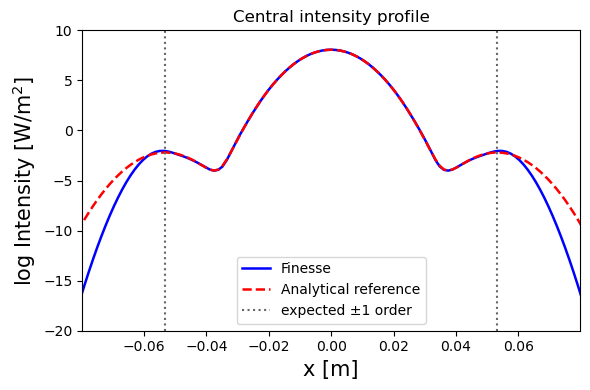

In [9]:
# laser power
P = 1 # [W]
# extract camera data from the Finesse solution
ccd_data = np.abs(np.array(sol_map["fcamera"]))**2

# central horizontal cut
npoints = ccd_data.shape[0]
idx = npoints // 2
profile_x = ccd_data[idx, :]
x_vals = np.linspace(-xmax, xmax, npoints)

# Expected first-order position from the grating equation
theta_1 = np.arcsin(Lambda * frequency)
d_ccd = (L) * np.tan(theta_1)

# Analytical solution along y = 0
I_analytic = analytical_ntensity(x=x_vals, y=np.zeros_like(x_vals), P=P, wavelength=Lambda, A=A, w0=waist, Lprop=L, frequency=frequency)


# Plot on logarithmic scale to enhance visibility of diffraction orders 
plt.figure(figsize=(6, 4))
plt.plot(x_vals, np.log(profile_x+1e-30), color="blue", lw=1.8, label="Finesse")
plt.plot(x_vals, np.log(I_analytic+1e-30), color="red", ls="--", lw=1.8, label="Analytical reference")
plt.axvline(+d_ccd, color="0.4", ls=":", label="expected ±1 order")
plt.axvline(-d_ccd, color="0.4", ls=":")
plt.ylim(-20, 10)
plt.xlim(-d_ccd * 1.5, d_ccd * 1.5)
plt.xlabel("x [m]", fontsize= 15)
plt.ylabel("log Intensity [W/m$^2$]", fontsize = 15)
plt.title("Central intensity profile")
plt.legend()
plt.tight_layout()
plt.show()

The first diffraction orders appear at the expected positions, but the field is not fully reproduced with `maxtem = 20`.

This is connected to the structure of the Hermite-Gauss basis, which is organised by transverse extent: as the mode order increases, the modes extend further from the optical axis. Representing light that appears at large transverse distances requires progressively higher-order modes, and the error is not uniform across the profile: it becomes more visible away from the optical axis, where the diffracted orders are located.

Below, we increase `maxtem` and compare the resulting field with the analytical reference solution, to determine when Finesse converges to the solution. 

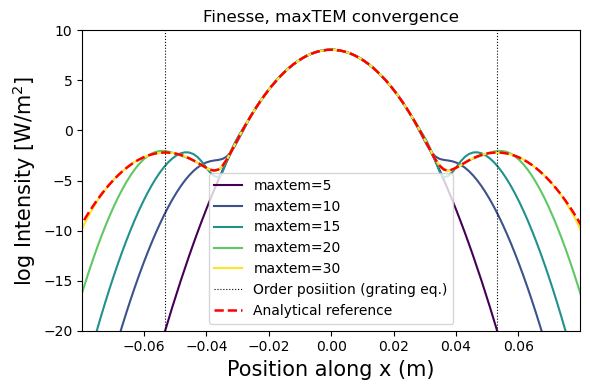

In [10]:
maxtems = [5, 10, 15, 20, 30]
colors = plt.cm.viridis(np.linspace(0, 1, len(maxtems)))

fig, ax = plt.subplots(figsize=(6, 4))

for maxtem_i, col in zip(maxtems, colors):
    model_i = model.deepcopy()
    model_i.modes(maxtem=maxtem_i)
    sol_i = model_i.run()
    
    data_i = np.abs(np.array(sol_i["fcamera"]))**2  
    idx_i = data_i.shape[0] // 2           
    cut_i = data_i[idx_i, :] 
    x_i = np.linspace(-xmax, xmax, data_i.shape[1])
    ax.plot(x_i, np.log(cut_i+1e-30), color=col, label=f"maxtem={maxtem_i}")

ax.axvline( d_ccd, c='k', ls=':', lw=0.8, label="Order posiition (grating eq.)")
ax.axvline(-d_ccd, c='k', ls=':', lw=0.8)
ax.plot(x_vals, np.log(I_analytic+1e-30), color="red", ls="--", lw=1.8, label="Analytical reference")
ax.set_xlabel("Position along x (m)", fontsize = 15)
ax.set_ylabel("log Intensity [W/m$^2$]", fontsize = 15)
ax.set_xlim(-d_ccd*1.5, d_ccd*1.5)
ax.set_ylim(-20, 10)
ax.legend(fontsize=10)
ax.set_title("Finesse, maxTEM convergence")
plt.tight_layout()
plt.show()

###  Propagate the field using FFT

We now repeat this analysis with FFT. The FFT propagation requires an explicit numerical grid. We define a 2D grid of 512 × 512 points covering a physical extent of 0.67 × 0.67 $\text{m}^2$, centred at the origin. The accuracy is controlled by the spatial sampling and by the size of the computational window. This gives a different type of error. If the grid is undersampled, the error affects the whole calculation globally.

In [11]:
xpoints = ypoints = 501
xsize = ysize = 0.67 
xoffset = yoffset = 0 

grid = Grid(xpoints, ypoints, xsize, ysize, xoffset, yoffset)
x_fft = grid.xaxis
y_fft = grid.yaxis

dx = xsize / xpoints
dy = ysize / ypoints
print(dx)

0.0013373253493013974


In FFT, we must define the input field explicitly on a grid. This field must be identical to the one Finesse uses (as we want to compare the two results to the same analytical reference): a Gaussian beam at z = 0 (the observation plane), with the same waist w_0, waist position z = 0, and the same surface and amplitude maps applied upon reflection at M1. 

In [12]:
# Start from M1 just before reflection
E_in = U_nm(x_fft, y_fft, 0, 0, q_mirror, Lambda)

We construct a 2D coordinate grid using `np.meshgrid` from the 1D FFT axes. This is necessary because the phase maps, mirror curvature and surface map are functions of both x and y and must be evaluated at every grid point. 

In [13]:
X, Y = np.meshgrid(x_fft,y_fft, indexing="xy")
R2 = X**2 + Y**2
k = 2 * np.pi / Lambda

# Apply both aperture, surface height and curvature maps: 
aperture = (np.sqrt(R2) <= mirror_radius).astype(float) 
phi_curv = k * R2 / RoC  
phi_map  =  2 * k * phase 

# define fields 
E_refl = aperture * E_in * np.exp(1j * ( phi_curv + phi_map))
E_refl_nomap = aperture *  E_in * np.exp(1j * ( phi_curv))

# fft propagate 
E_map_fft = fft_propagate(E_refl, grid, Lambda, L, refaction_index=1)

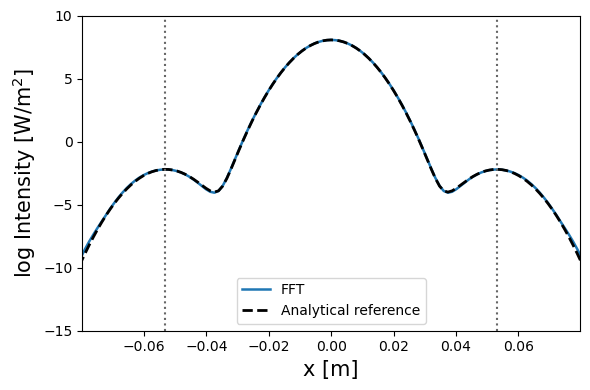

In [14]:
# intensity
I_fft = np.abs(E_map_fft)**2

# central horizontal cut
idx = I_fft.shape[0] // 2
profile_fft = I_fft[idx, :]


plt.figure(figsize=(6,4))

plt.plot(x_fft, np.log(profile_fft + 1e-30), lw=1.8, label="FFT")
plt.plot(x_fft, np.log(I_analytic + 1e-30), "k--", lw=2, label="Analytical reference")
plt.axvline(+d_ccd, color="0.4", ls=":")
plt.axvline(-d_ccd, color="0.4", ls=":")
plt.xlim(-1.5*d_ccd, 1.5*d_ccd)
plt.ylim(-15,10)
plt.xlabel("x [m]", fontsize = 15)
plt.ylabel("log Intensity [W/m$^2$]", fontsize = 15)
plt.legend(fontsize = 10)
plt.tight_layout()
plt.show()

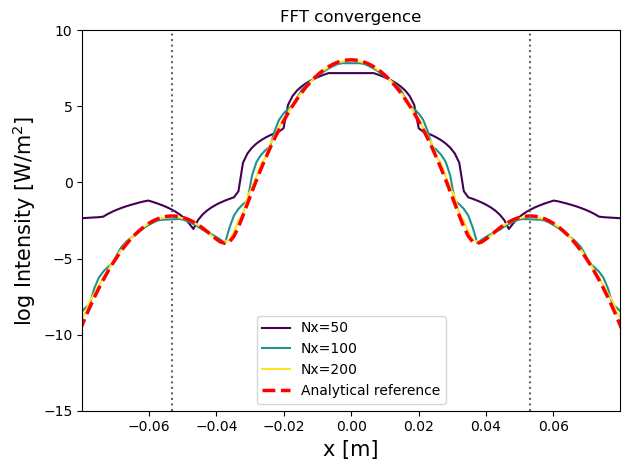

In [15]:
Nx_list = [50, 100, 200]

fft_profiles = {}

for Nx in Nx_list:

    grid_t = Grid(Nx, Nx, xsize, xsize, 0, 0)
    x_t = grid_t.xaxis
    y_t = grid_t.yaxis
    Xt, Yt = np.meshgrid(x_t, y_t, indexing="xy")
    R2_t = Xt**2 + Yt**2
    aperture_t = (np.sqrt(R2_t) <= mirror_radius).astype(float)
    E_in_t = np.sqrt(P) * U_nm(x_t, y_t, 0, 0, q_mirror, Lambda)
    phase_t = A * np.cos(2*np.pi*frequency*Xt)
    E_refl_t = (aperture_t * E_in_t* np.exp(1j * (k*R2_t/RoC + 2*k*phase_t)))
    E_fft_t = fft_propagate(E_refl_t,  grid_t, Lambda, L, refaction_index=1)
    I_fft_t = np.abs(E_fft_t)**2
    iy = Nx // 2
    profile_t = I_fft_t[iy, :]
    profile_interp = np.interp( x_fft, x_t, profile_t)
    fft_profiles[Nx] = profile_interp


colors = plt.cm.viridis(np.linspace(0, 1, len(Nx_list)))

for c, Nx in zip(colors, Nx_list):

    plt.plot(x_fft, np.log(fft_profiles[Nx]),color=c, label=f"Nx={Nx}")

plt.plot(x_fft, np.log(I_analytic+1e-30), color='red', ls="--", lw=2.5, label="Analytical reference")

plt.axvline(+d_ccd, color="0.4", ls=":")
plt.axvline(-d_ccd, color="0.4", ls=":")
plt.xlim(-1.5*d_ccd, 1.5*d_ccd)
plt.ylim(-15, 10)
plt.xlabel("x [m]", fontsize = 15)
plt.ylabel("log Intensity [W/m$^2$]", fontsize = 15)
plt.title("FFT convergence")
plt.legend(fontsize = 10)
plt.tight_layout()
plt.show()